### Problem 1
Implement serial test and apply to a `samples`

In [1]:
import numpy as np
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1
samples = [rng() for _ in range(1000)]

def serial_test(samples, k=10):
    n_pairs = len(samples) // 2
    pairs = np.array(samples[:n_pairs * 2]).reshape(-1, 2)
    
    grid_bins = [np.linspace(0, 1, k + 1), np.linspace(0, 1, k + 1)]
    f_obs, _, _ = np.histogram2d(pairs[:, 0], pairs[:, 1], bins=grid_bins)
    
    f_obs = f_obs.flatten()
    f_exp = np.full(k * k, n_pairs / (k * k))
    
    return stats.chisquare(f_obs, f_exp)

result = serial_test(samples)

print(f"Statistic: {result.statistic}")
print(f"p-value: {result.pvalue}")

if result.pvalue < 0.05:
    print("Reject H0: distribution is not uniform")
else:
    print("Do not reject H0: no evidence against uniform distribution")

Statistic: 114.39999999999999
p-value: 0.1380441495447643
Do not reject H0: no evidence against uniform distribution


### Problem 2*
Implement permutation test and apply to a `samples`

In [2]:
import numpy as np
from scipy import stats
import math

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1
samples = [rng() for _ in range(1000)]

def permutation_test(samples, n=3):
    num_groups = len(samples) // n
    groups = np.array(samples[:num_groups * n]).reshape(-1, n)
    
    possible_permutations = list(math.factorial(n) * [0])
    
    observed_counts = {}
    
    for group in groups:
        indices = np.argsort(group)
        perm = tuple(indices)
        observed_counts[perm] = observed_counts.get(perm, 0) + 1
    
    f_obs = []
    import itertools
    for p in itertools.permutations(range(n)):
        f_obs.append(observed_counts.get(p, 0))
        
    f_exp = np.full(len(f_obs), num_groups / math.factorial(n))
    
    return stats.chisquare(f_obs, f_exp)

result = permutation_test(samples, n=3)

print(f"Statistic: {result.statistic}")
print(f"p-value: {result.pvalue}")

if result.pvalue < 0.05:
    print("Reject H0: distribution of permutations is not uniform")
else:
    print("Do not reject H0: no evidence against uniform distribution")

Statistic: 4.8558558558558556
p-value: 0.4337239950364655
Do not reject H0: no evidence against uniform distribution


### Problem 3

Provide a statistical test to show that `rng_bad` has problems but `rng_good` does not.

In [ ]:
import numpy as np
from scipy import stats

def rng_good(m=2**32, a=1103515245, c=12345):
    rng_good.current = (a * rng_good.current + c) % m
    return rng_good.current / m

def rng_bad(m=2**31, a=65539, c=0):
    rng_bad.current = (a * rng_bad.current + c) % m
    return rng_bad.current / m

def serial_test_3d(samples, k=12):
    n_points = len(samples) // 3
    data_3d = np.array(samples[:n_points * 3]).reshape(-1, 3)
    
    edges = [np.linspace(0, 1, k + 1)] * 3
    f_obs, _ = np.histogramdd(data_3d, bins=edges)
    
    f_obs_flat = f_obs.flatten()
    f_exp = np.full(k**3, n_points / (k**3))
    
    return stats.chisquare(f_obs_flat, f_exp)

n_total = 30000

rng_good.current = 1
data_good = [rng_good() for _ in range(n_total)]

rng_bad.current = 1
data_bad = [rng_bad() for _ in range(n_total)]

res_good = serial_test_3d(data_good)
res_bad = serial_test_3d(data_bad)

print("--- Evaluation: High-Quality LCG ---")
print(f"Chi2 Stat: {res_good.statistic:.4f}")
print(f"P-Value: {res_good.pvalue:.4f}")
print(f"Uniform distribution: {res_good.pvalue >= 0.05}")

print("\n--- Evaluation: RANDU (Bad LCG) ---")
print(f"Chi2 Stat: {res_bad.statistic:.4f}")
print(f"P-Value: {res_bad.pvalue:.4e}")
print(f"Uniform distribution: {res_bad.pvalue >= 0.05}")

--- Evaluation: High-Quality LCG ---
Chi2 Stat: 1643.6096
P-Value: 0.9238
Uniform distribution: True

--- Evaluation: RANDU (Bad LCG) ---
Chi2 Stat: 2398.4000
P-Value: 8.0585e-25
Uniform distribution: False


### Problem 4
Simulate a sample of 1000 from a discrete distribution on a set of digits $0, 1, 2, \ldots, 9$ with weights $0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2$. Construct a histogram from the sample. Optimise the algorithm by ordering the weights.

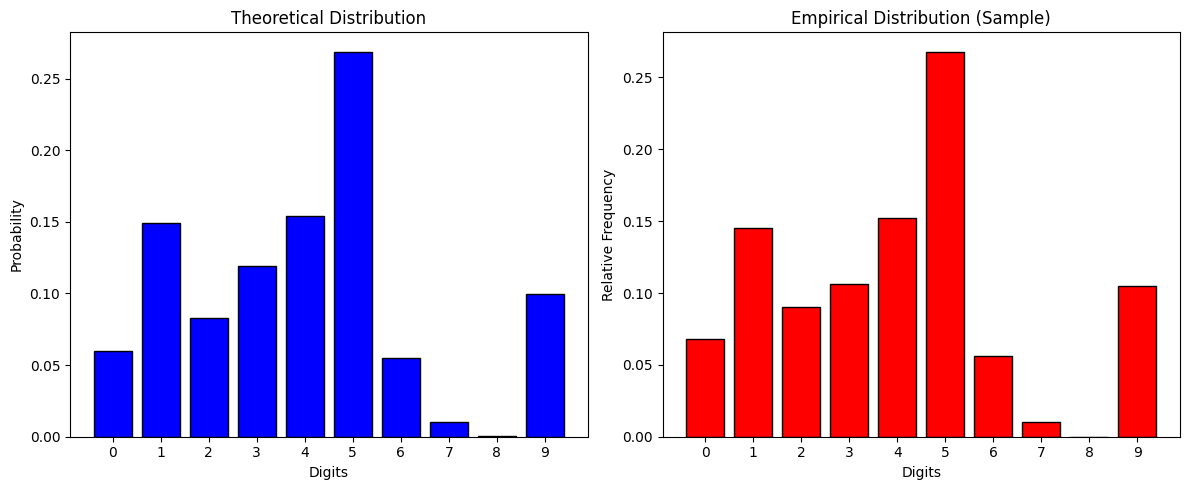

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
digits = np.arange(10)

sorted_indices = np.argsort(weights)[::-1]
sorted_weights = weights[sorted_indices]
sorted_digits = digits[sorted_indices]

probabilities = sorted_weights / sorted_weights.sum()
cumulative_probs = np.cumsum(probabilities)

sample = []
for _ in range(1000):
    u = rng()
    for i in range(len(cumulative_probs)):
        if u < cumulative_probs[i]:
            sample.append(sorted_digits[i])
            break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(digits, weights / weights.sum(), color='blue', edgecolor='black')
ax1.set_title('Theoretical Distribution')
ax1.set_xlabel('Digits')
ax1.set_ylabel('Probability')
ax1.set_xticks(digits)

ax2.hist(sample, bins=np.arange(11)-0.5, rwidth=0.8, density=True, color='red', edgecolor='black')
ax2.set_title('Empirical Distribution (Sample)')
ax2.set_xlabel('Digits')
ax2.set_ylabel('Relative Frequency')
ax2.set_xticks(digits)

plt.tight_layout()
plt.show()

### Problem 5
Simulate a sample of size 1000 from the distribution $\operatorname{Exp}(\lambda)$ using the Inverse transform method. Construct a sample histogram and an accurate plot of the distribution density.

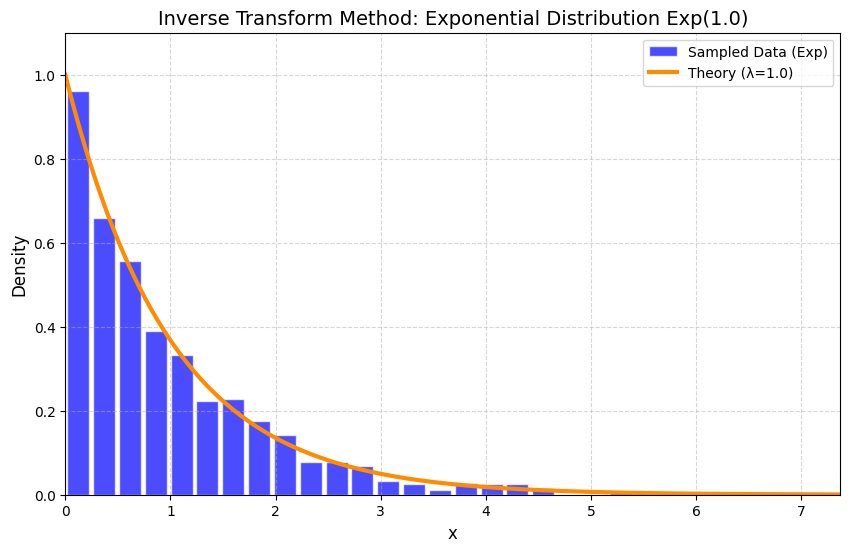

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

lam = 1.0
sample = []

for _ in range(1000):
    u = rng()
    x = - (1 / lam) * np.log(u)
    sample.append(x)

x_vals = np.linspace(0, max(sample), 200)
y_vals = lam * np.exp(-lam * x_vals)

plt.figure(figsize=(10, 6))
plt.hist(sample, bins=30, density=True, alpha=0.7, color='blue', 
         edgecolor='white', rwidth=0.85, label='Sampled Data (Exp)')
plt.plot(x_vals, y_vals, color='darkorange', lw=3, label=f'Theory (λ={lam})')

plt.xlim(0, max(sample))
plt.ylim(0, lam + 0.1)
plt.grid(True, linestyle='--', alpha=0.5)

plt.title(f'Inverse Transform Method: Exponential Distribution Exp({lam})', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()

plt.show()

### Problem 6
Justify (orally) that the accept-reject method really samples from the required distribution. Simulate $1000$ points from the distribution with density $$e^xcos^2x \cdot \mathbb{I}_{[-\frac\pi2, \frac\pi2]}$$. Plot the sampled histogram on the sample and compare it with the plot of the exact density function.

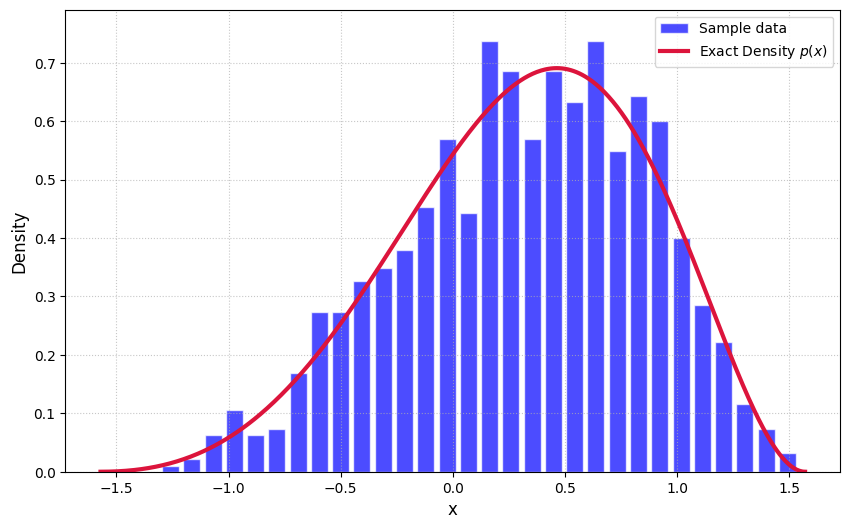

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

def f(x):
    return np.exp(x) * (np.cos(x)**2)

norm_const, _ = quad(f, -np.pi/2, np.pi/2)

def p(x):
    return f(x) / norm_const

x_grid = np.linspace(-np.pi/2, np.pi/2, 1000)
M = np.max(p(x_grid))

sample = []
while len(sample) < 1000:
    u1 = rng()
    u2 = rng()
    
    x_cand = u1 * np.pi - np.pi/2
    y_cand = u2 * M
    
    if y_cand <= p(x_cand):
        sample.append(x_cand)

x_plot = np.linspace(-np.pi/2, np.pi/2, 500)
y_plot = p(x_plot)

plt.figure(figsize=(10, 6))
plt.hist(sample, bins=30, density=True, alpha=0.7, color='blue', 
         edgecolor='white', rwidth=0.8, label = "Sample data")
plt.plot(x_plot, y_plot, color='crimson', lw=3, label='Exact Density $p(x)$')

plt.grid(True, linestyle=':', alpha=0.7)
plt.ylim(0, M + 0.1)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.show()

### Problem 7
Model and depict a sample of 500 points uniformly distributed within a given triangle without using a selection method.

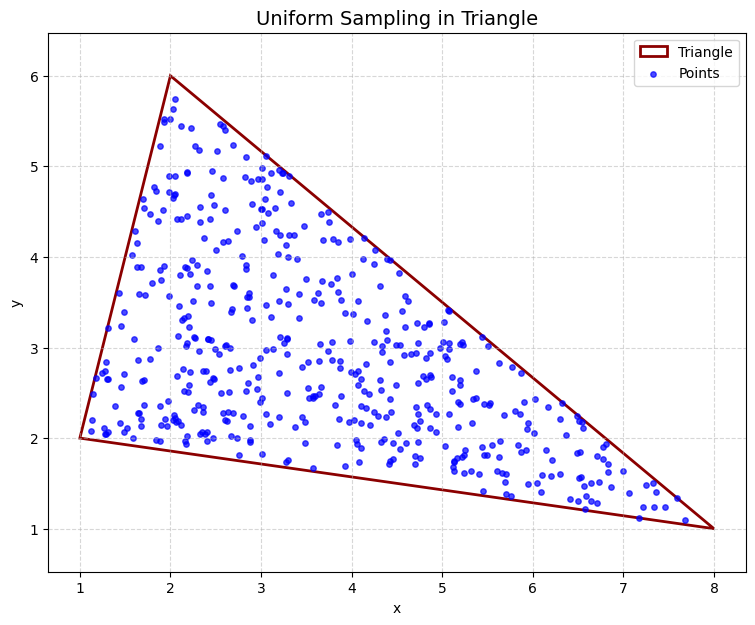

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

A = np.array([1, 2])
B = np.array([2, 6])
C = np.array([8, 1])

v1 = B - A
v2 = C - A

sample = []
for _ in range(500):
    u1 = rng()
    u2 = rng()
    
    if u1 + u2 > 1:
        u1 = 1 - u1
        u2 = 1 - u2
    
    P = A + u1 * v1 + u2 * v2
    sample.append(P)

sample = np.array(sample)

plt.figure(figsize=(9, 7))
triangle = plt.Polygon([A, B, C], fill=False, edgecolor='darkred', lw=2, label='Triangle')
plt.gca().add_patch(triangle)

plt.scatter(sample[:, 0], sample[:, 1], s=15, color='blue', alpha=0.7, label='Points')

plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.title('Uniform Sampling in Triangle', fontsize=14)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Problem 8
Model without using the selection method a sample of $500$ points uniformly distributed inside the unit circle. Picture the obtained points. Do they really fill the circle uniformly?

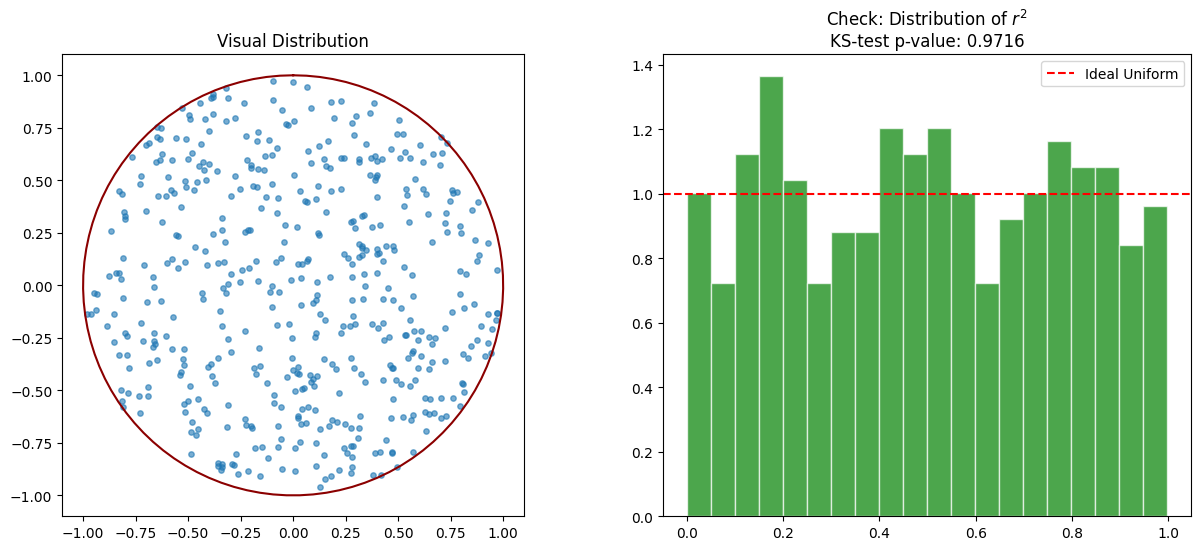

Статистика теста: 0.0215
p-value: 0.9716
Равномерно? Да


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

radii_squared = []
sample = []

for _ in range(500):
    u_phi = rng()
    u_r = rng()
    
    phi = 2 * np.pi * u_phi
    r = np.sqrt(u_r)
    
    radii_squared.append(r**2) 
    sample.append([r * np.cos(phi), r * np.sin(phi)])

sample = np.array(sample)

ks_stat, p_value = stats.kstest(radii_squared, 'uniform')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

t = np.linspace(0, 2*np.pi, 100)
ax1.plot(np.sin(t), np.cos(t), color='darkred')
ax1.scatter(sample[:, 0], sample[:, 1], s=15, alpha=0.6)
ax1.set_aspect('equal')
ax1.set_title("Visual Distribution")

ax2.hist(radii_squared, bins=20, density=True, color='green', edgecolor='white', alpha=0.7)
ax2.axhline(1, color='red', linestyle='--', label='Ideal Uniform')
ax2.set_title(f"Check: Distribution of $r^2$\nKS-test p-value: {p_value:.4f}")
ax2.legend()

plt.show()

print(f"Статистика теста: {ks_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print("Равномерно?" , "Да" if p_value > 0.05 else "Нет")

### Problem 9
Prove (orally) that the following algorithm (**Box-Muller algorithm**, https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) generates a sample of independent $\mathcal{N}(0,1)$ random variables. Modify the method to exclude calls of trigonometric functions `np.sin` and `np.cos`. Using the modified method, simulate a sample size of $1000$ from a $2D$ Gaussian distribution with mean $\mu$ and covariance matrix $\Sigma$, where
$$\mu = \begin{pmatrix} 4 \\ 7 \end{pmatrix}^T, \quad \Sigma = \begin{pmatrix} 20 & -4 \\ -4 & 40 \end{pmatrix}.$$
Construct a 2D histogram of the resulting distribution. Compare the sample mean and covariance matrix with the exact values.

--- MEAN ---
Theoretical: [4 7]
Sample:      [4.157 7.125]

--- COVARIANCE MATRIX ---
Theoretical:
[[20 -4]
 [-4 40]]
Sample:
[[21.735 -3.816]
 [-3.816 40.13 ]]


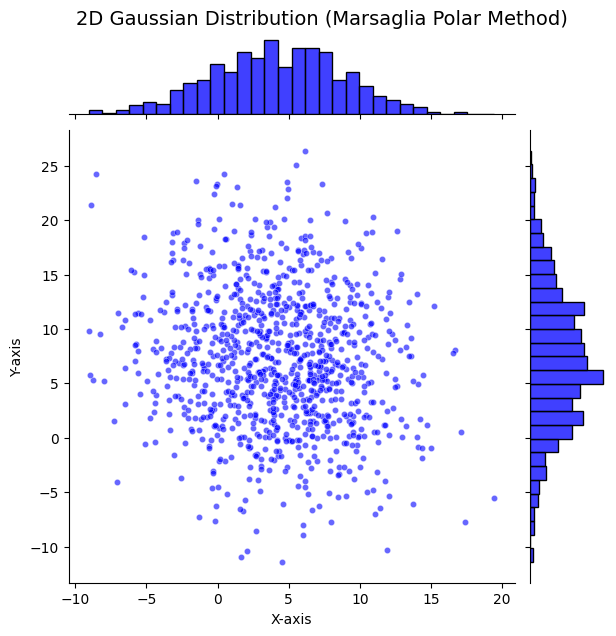

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def rng(m=2**32, a=1103515245, c=12345):
    rng.current = (a * rng.current + c) % m
    return rng.current / m

rng.current = 1

z1 = []
z2 = []

while len(z1) < 1000:
    u = rng() * 2 - 1
    v = rng() * 2 - 1
    s = u**2 + v**2
    
    if 0 < s <= 1:
        mult = np.sqrt(-2 * np.log(s) / s)
        z1.append(u * mult)
        z2.append(v * mult)

Z = np.array([z1, z2])

mu = np.array([4, 7])
cov = np.array([[20, -4], [-4, 40]])

L = np.linalg.cholesky(cov)

X = mu[:, None] + L @ Z
x_sample, y_sample = X[0, :], X[1, :]

sample_mu = np.mean(X, axis=1)
sample_cov = np.cov(X)

print("--- MEAN ---")
print(f"Theoretical: {mu}")
print(f"Sample:      {np.round(sample_mu, 3)}")

print("\n--- COVARIANCE MATRIX ---")
print("Theoretical:")
print(cov)
print("Sample:")
print(np.round(sample_cov, 3))

g = sns.jointplot(x=x_sample, y=y_sample, kind="scatter", 
                  color="blue", s=20, alpha=0.6, 
                  marginal_kws=dict(bins=30, fill=True, color="blue"))

g.set_axis_labels('X-axis', 'Y-axis')
plt.suptitle('2D Gaussian Distribution (Marsaglia Polar Method)', y=1.02, fontsize=14)
plt.show()